<a href="https://www.kaggle.com/code/omborse771924/ai-impact-in-future-on-jobs-market-in-2030-eda?scriptVersionId=322819670" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030/AI_Impact_on_Jobs_2030.csv


## Loading Dataset



In [2]:
df = pd.read_csv('/kaggle/input/datasets/muhammadwaqas023/ai-impact-in-future-on-jobs-market-in-2030/AI_Impact_on_Jobs_2030.csv')

In [3]:
df.head()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


In [4]:
df.tail()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
2995,AIJ-102995,Data Scientist,Education,India,Bachelor,0,0.62,0.27,Hybrid,202565,"Azure, Project Management, Cloud Computing, Cy...",Medium,36,59,Enterprise,Moderate,4.54,Yes,1.27,Stable
2996,AIJ-102996,Data Engineer,Healthcare,UAE,PhD,4,0.52,0.57,Yes,37215,"Communication, PyTorch, Docker",Low,17,45,Startup,Low,2.71,No,2.56,Stable
2997,AIJ-102997,DevOps Engineer,Energy,Pakistan,High School,7,0.72,0.70,No,55179,"TensorFlow, Excel, Python, Docker",Medium,34,35,Startup,Low,4.88,Yes,3.17,Declining
2998,AIJ-102998,Data Scientist,Government,Australia,Bachelor,19,0.82,0.76,Hybrid,125291,"Cybersecurity, Cloud Computing, Deep Learning",Medium,21,47,Startup,Moderate,3.59,Yes,3.78,Stable
2999,AIJ-102999,HR Specialist,Retail,Germany,Master,9,0.68,0.44,No,152792,"Kubernetes, Cybersecurity, Communication",Low,32,44,Medium,Moderate,3.29,No,1.36,Growing


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Employee_ID              3000 non-null   object 
 1   Job_Title                3000 non-null   object 
 2   Industry                 3000 non-null   object 
 3   Country                  3000 non-null   object 
 4   Education_Level          3000 non-null   object 
 5   Years_Experience         3000 non-null   int64  
 6   AI_Replacement_Risk      3000 non-null   float64
 7   Future_Demand_Score      3000 non-null   float64
 8   Remote_Work_Possibility  3000 non-null   object 
 9   Average_Salary_USD       3000 non-null   int64  
 10  Required_Skills          3000 non-null   object 
 11  Automation_Level         3000 non-null   object 
 12  Job_Growth_2030          3000 non-null   int64  
 13  Work_Hours_Per_Week      3000 non-null   int64  
 14  Company_Size            

In [6]:
df.describe()

,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Average_Salary_USD,Job_Growth_2030,Work_Hours_Per_Week,Performance_Score,Job_Satisfaction
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,12.383000,0.502910,0.601203,126641.746667,17.238333,44.773333,3.514643,3.026167
std,7.528958,0.261293,0.226674,55405.053057,16.230322,8.926469,0.873375,1.146361
min,0.000000,0.050000,0.200000,30221.000000,-10.000000,30.000000,2.000000,1.000000
25%,6.000000,0.280000,0.420000,77262.000000,3.000000,37.000000,2.760000,2.060000
50%,12.000000,0.500000,0.600000,127660.500000,17.000000,45.000000,3.540000,3.025000
75%,19.000000,0.730000,0.800000,174811.750000,31.000000,52.000000,4.270000,4.010000
max,25.000000,0.950000,0.990000,219998.000000,45.000000,60.000000,5.000000,5.000000


In [7]:
df.isnull()

,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [8]:
df.isnull().sum()

Employee_ID                0
Job_Title                  0
Industry                   0
Country                    0
Education_Level            0
Years_Experience           0
AI_Replacement_Risk        0
Future_Demand_Score        0
Remote_Work_Possibility    0
Average_Salary_USD         0
Required_Skills            0
Automation_Level           0
Job_Growth_2030            0
Work_Hours_Per_Week        0
Company_Size               0
AI_Tool_Usage              0
Performance_Score          0
Upskilling_Needed          0
Job_Satisfaction           0
Hiring_Trend_2026          0
dtype: int64

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.columns

Index(['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level',
       'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills',
       'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Company_Size', 'AI_Tool_Usage', 'Performance_Score',
       'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026'],
      dtype='object')

## EDA

Dataset Shape : (3000, 20)

Columns :
 Index(['Employee_ID', 'Job_Title', 'Industry', 'Country', 'Education_Level',
       'Years_Experience', 'AI_Replacement_Risk', 'Future_Demand_Score',
       'Remote_Work_Possibility', 'Average_Salary_USD', 'Required_Skills',
       'Automation_Level', 'Job_Growth_2030', 'Work_Hours_Per_Week',
       'Company_Size', 'AI_Tool_Usage', 'Performance_Score',
       'Upskilling_Needed', 'Job_Satisfaction', 'Hiring_Trend_2026'],
      dtype='object')


,Employee_ID,Job_Title,Industry,Country,Education_Level,Years_Experience,AI_Replacement_Risk,Future_Demand_Score,Remote_Work_Possibility,Average_Salary_USD,Required_Skills,Automation_Level,Job_Growth_2030,Work_Hours_Per_Week,Company_Size,AI_Tool_Usage,Performance_Score,Upskilling_Needed,Job_Satisfaction,Hiring_Trend_2026
0,AIJ-100000,Data Engineer,Healthcare,Japan,PhD,1,0.25,0.78,Yes,207392,"Python, Communication, Deep Learning",Low,3,37,Enterprise,High,2.08,Yes,3.86,Growing
1,AIJ-100001,Healthcare Analyst,Retail,UK,Bachelor,24,0.73,0.33,No,140785,"Deep Learning, Azure, Communication, TensorFlo...",Low,-5,42,Startup,Moderate,4.54,No,4.23,Growing
2,AIJ-100002,HR Specialist,Education,Canada,High School,21,0.80,0.69,Yes,124800,"Kubernetes, Cloud Computing, TensorFlow, SQL, ...",Medium,-5,57,Startup,Low,3.14,No,3.54,Stable
3,AIJ-100003,Cybersecurity Analyst,Government,UK,Bachelor,5,0.29,0.94,No,199878,"Excel, Kubernetes, Prompt Engineering, Leadership",Medium,7,59,Enterprise,High,3.67,No,4.37,Declining
4,AIJ-100004,Healthcare Analyst,Education,UAE,PhD,20,0.11,0.92,No,178682,"SQL, Leadership, TensorFlow, Cybersecurity",Low,6,34,Startup,High,3.68,No,3.99,Stable


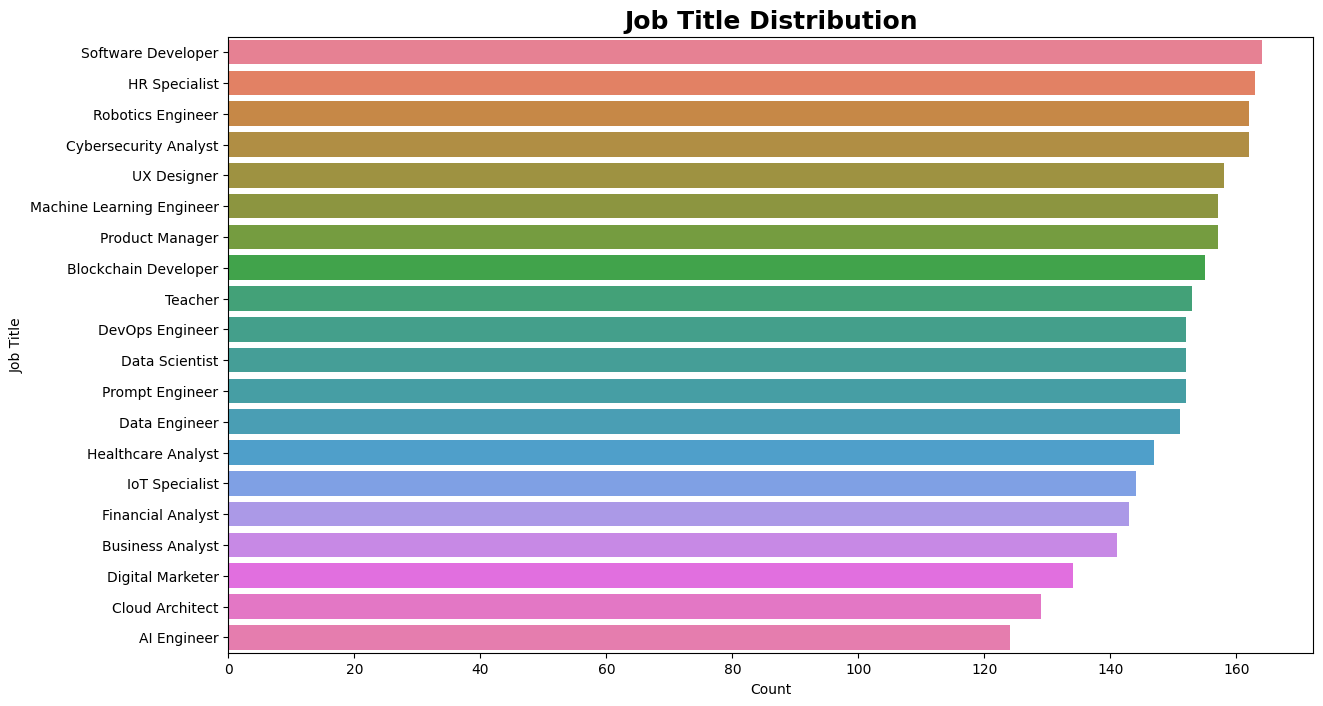

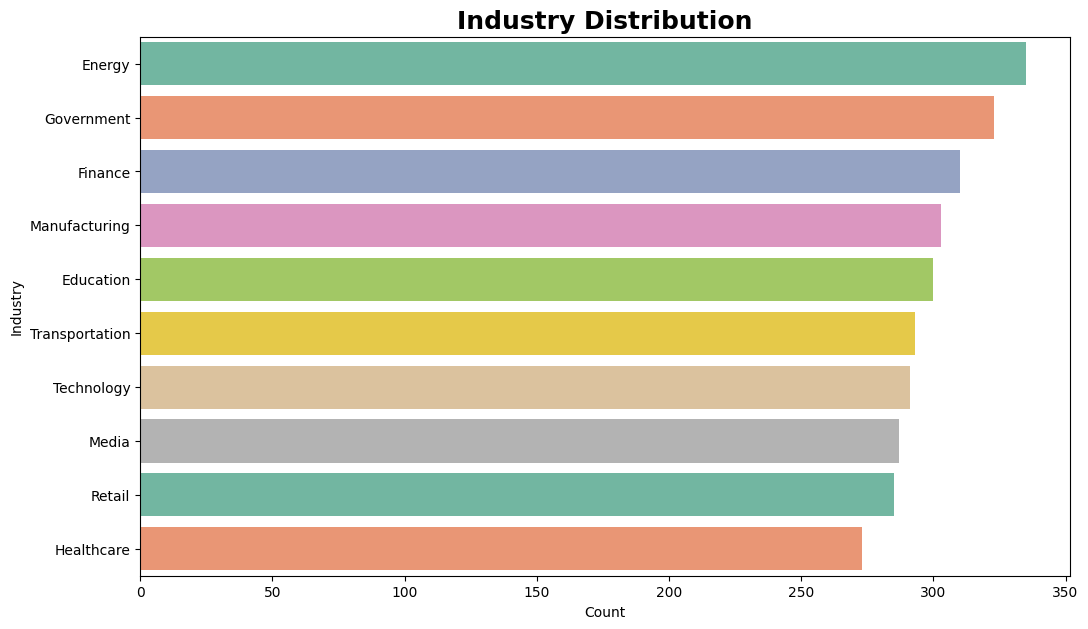

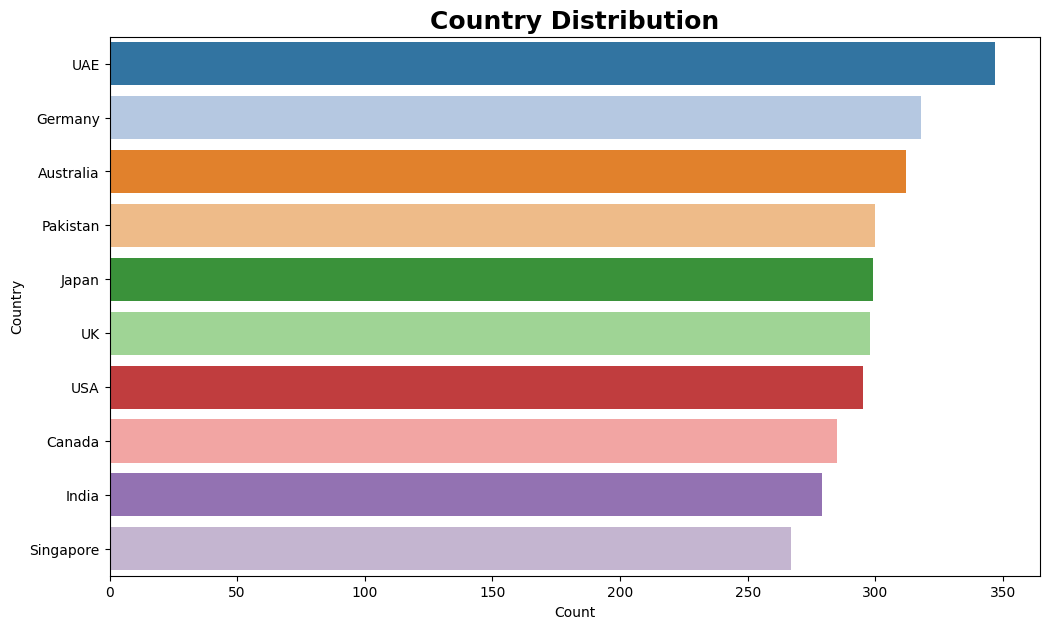

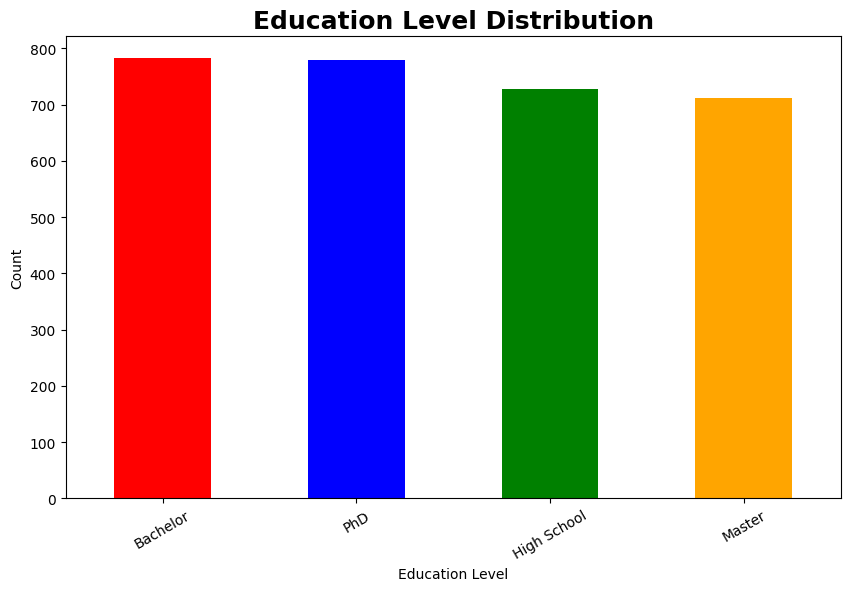

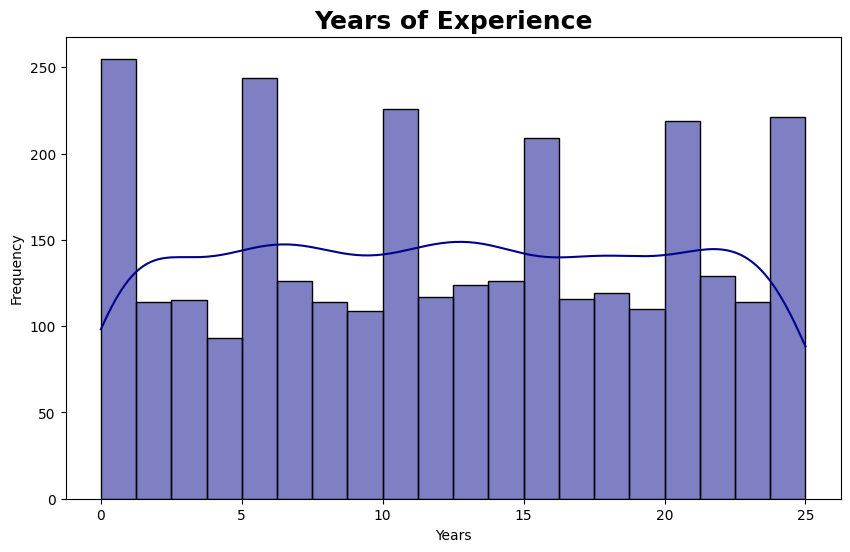

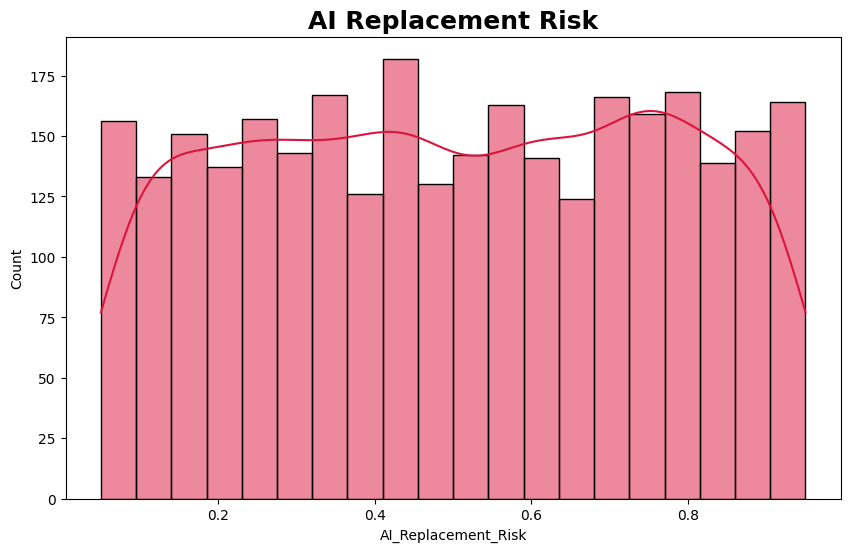

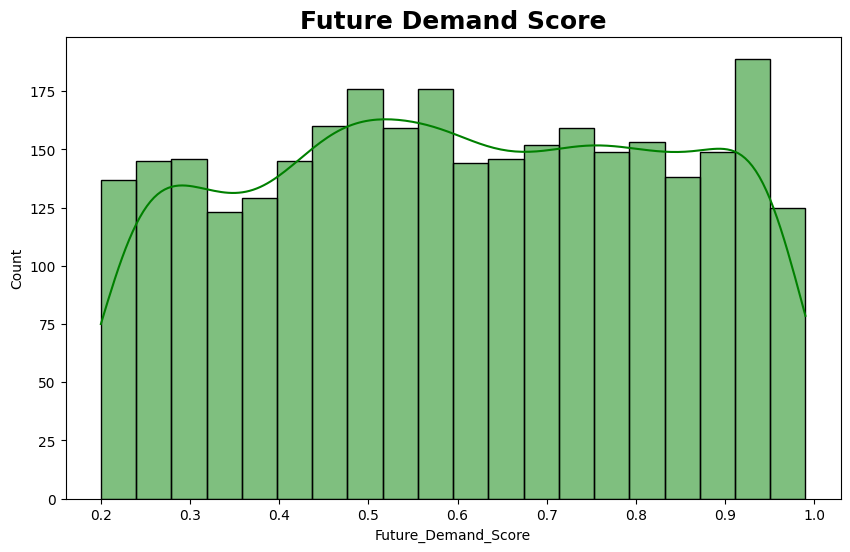

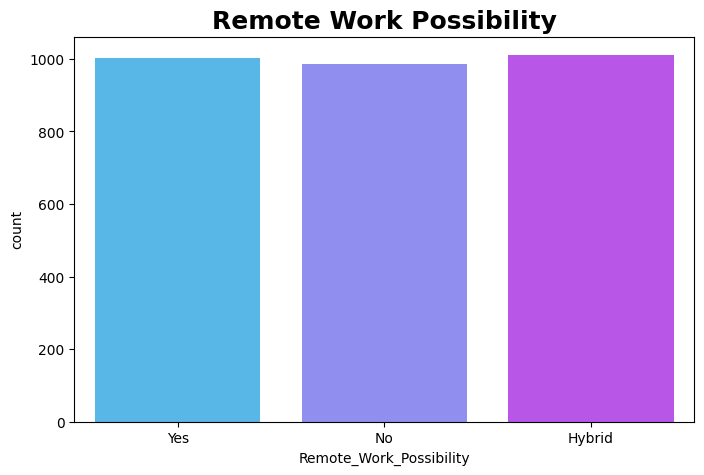

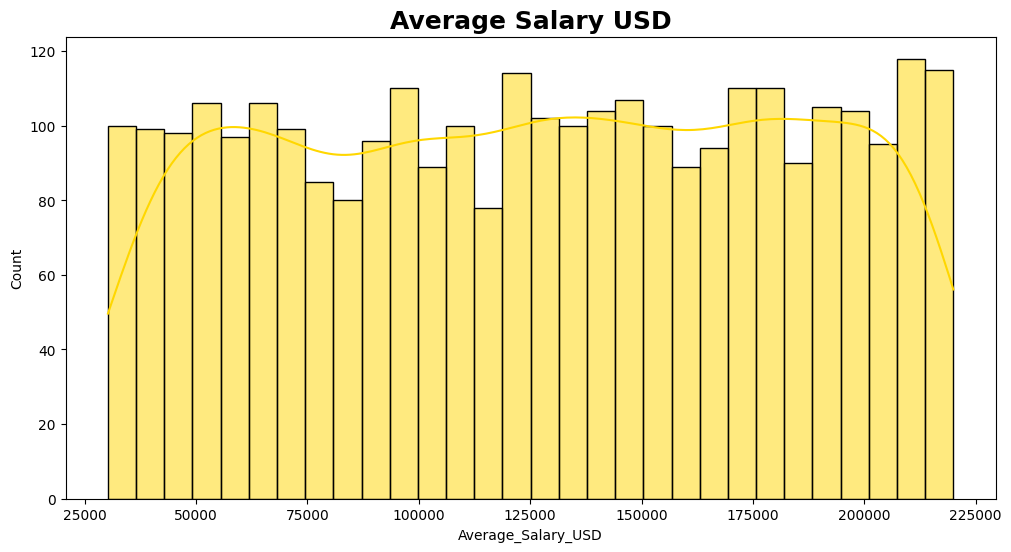

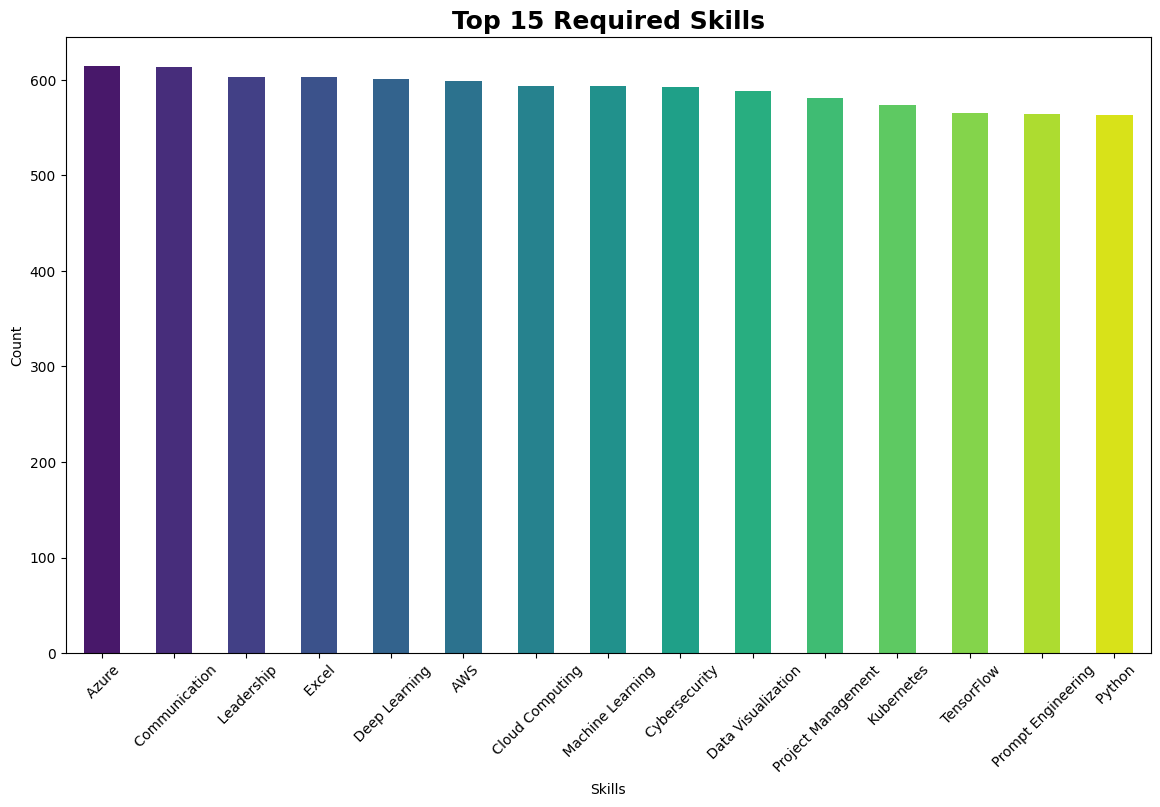

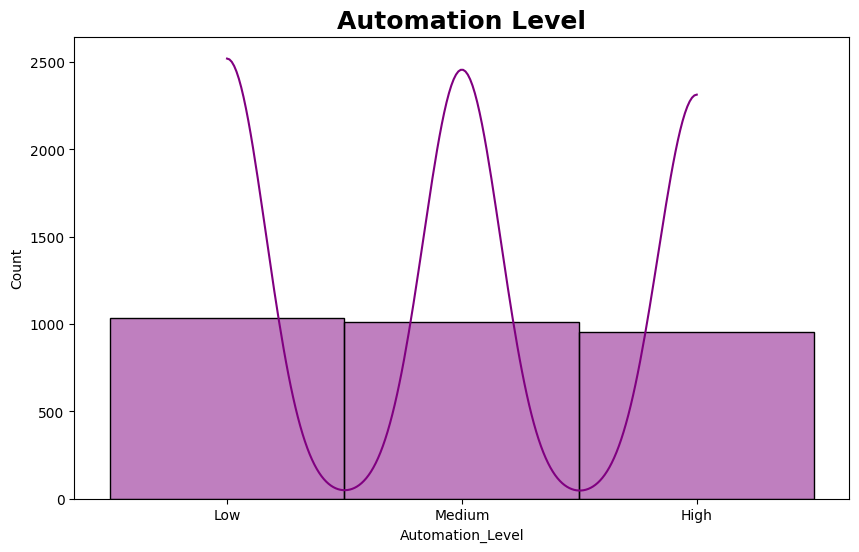

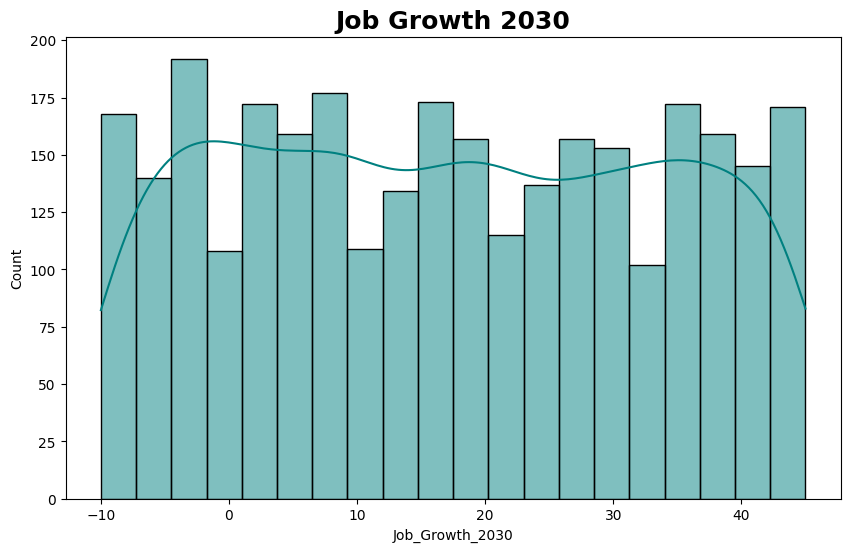

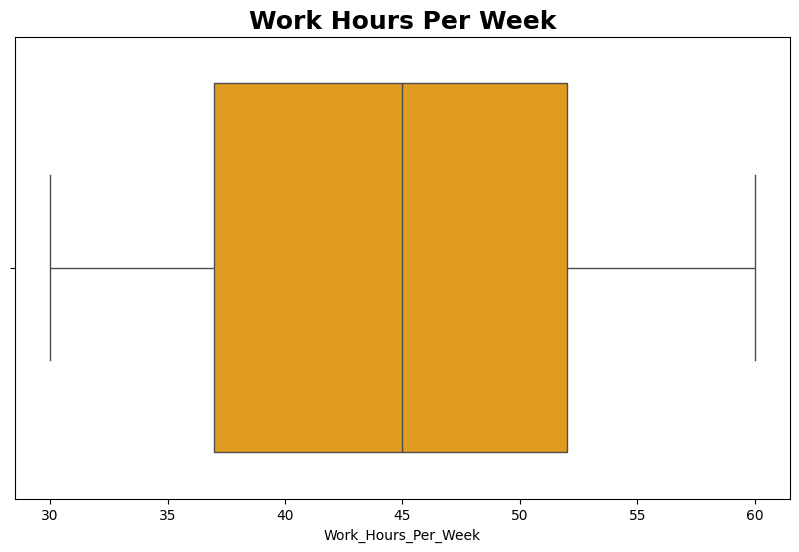

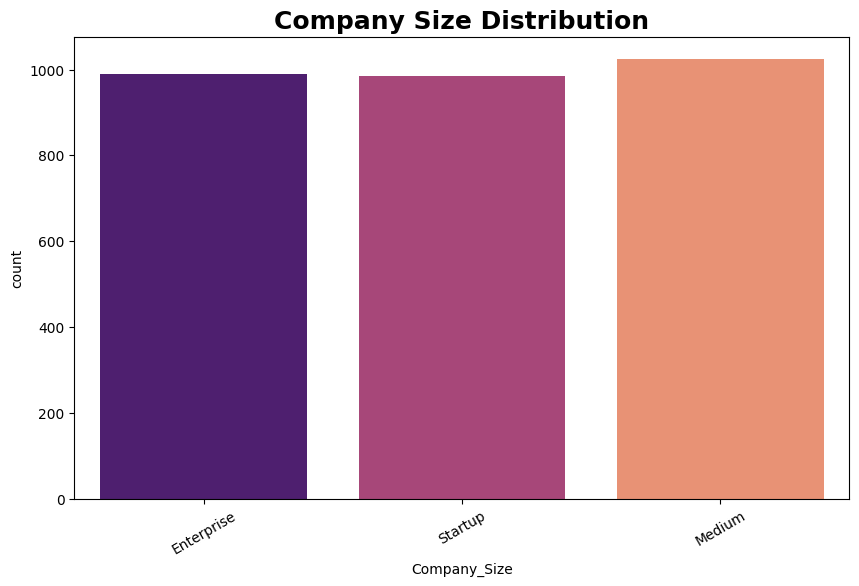

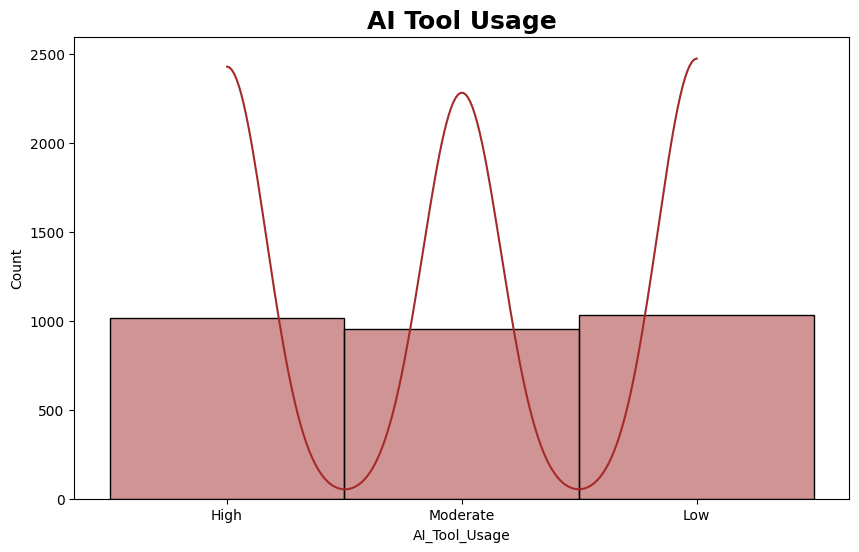

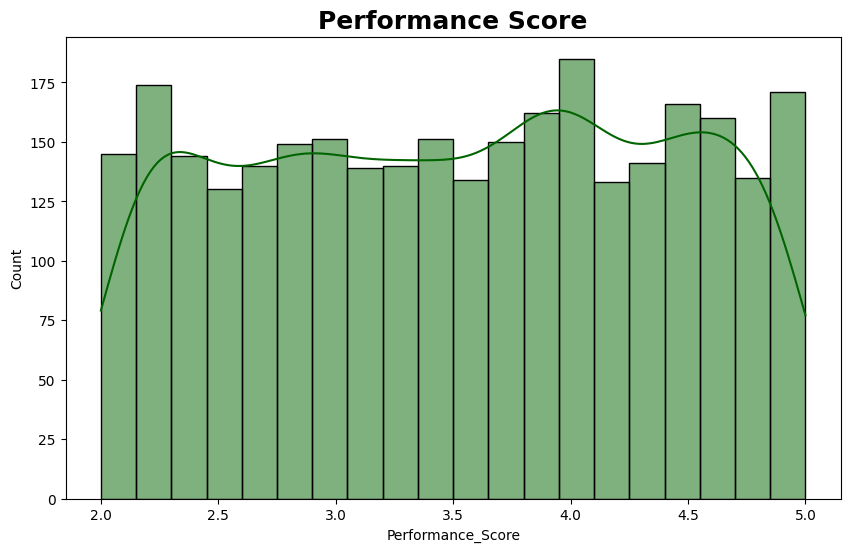

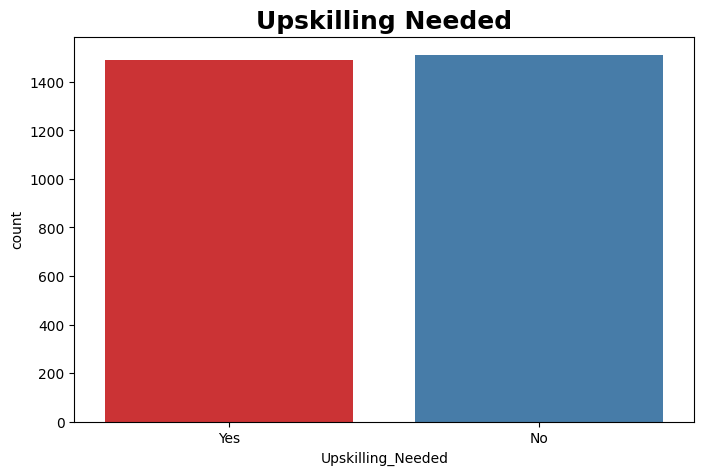

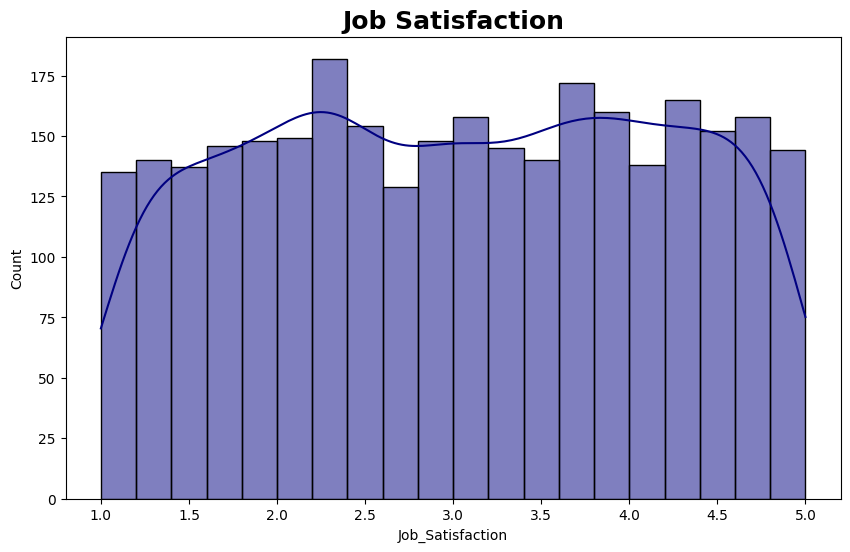

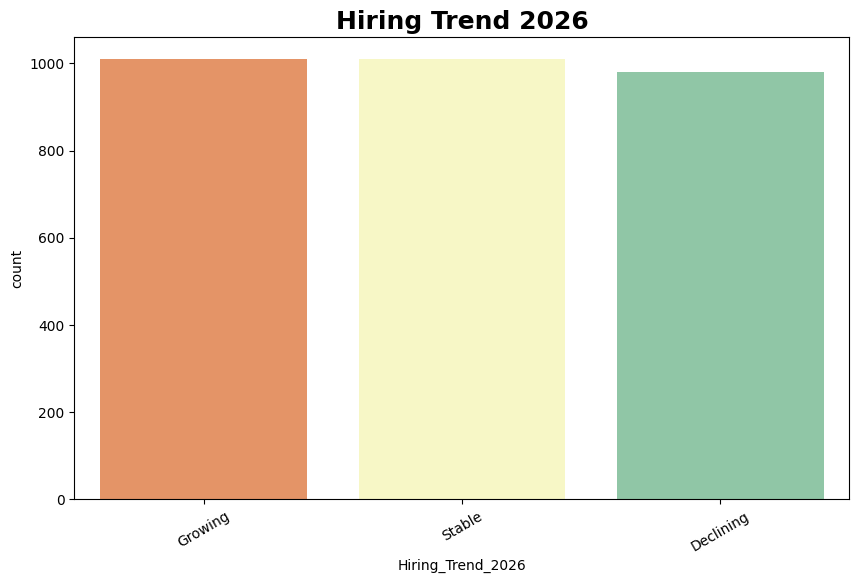

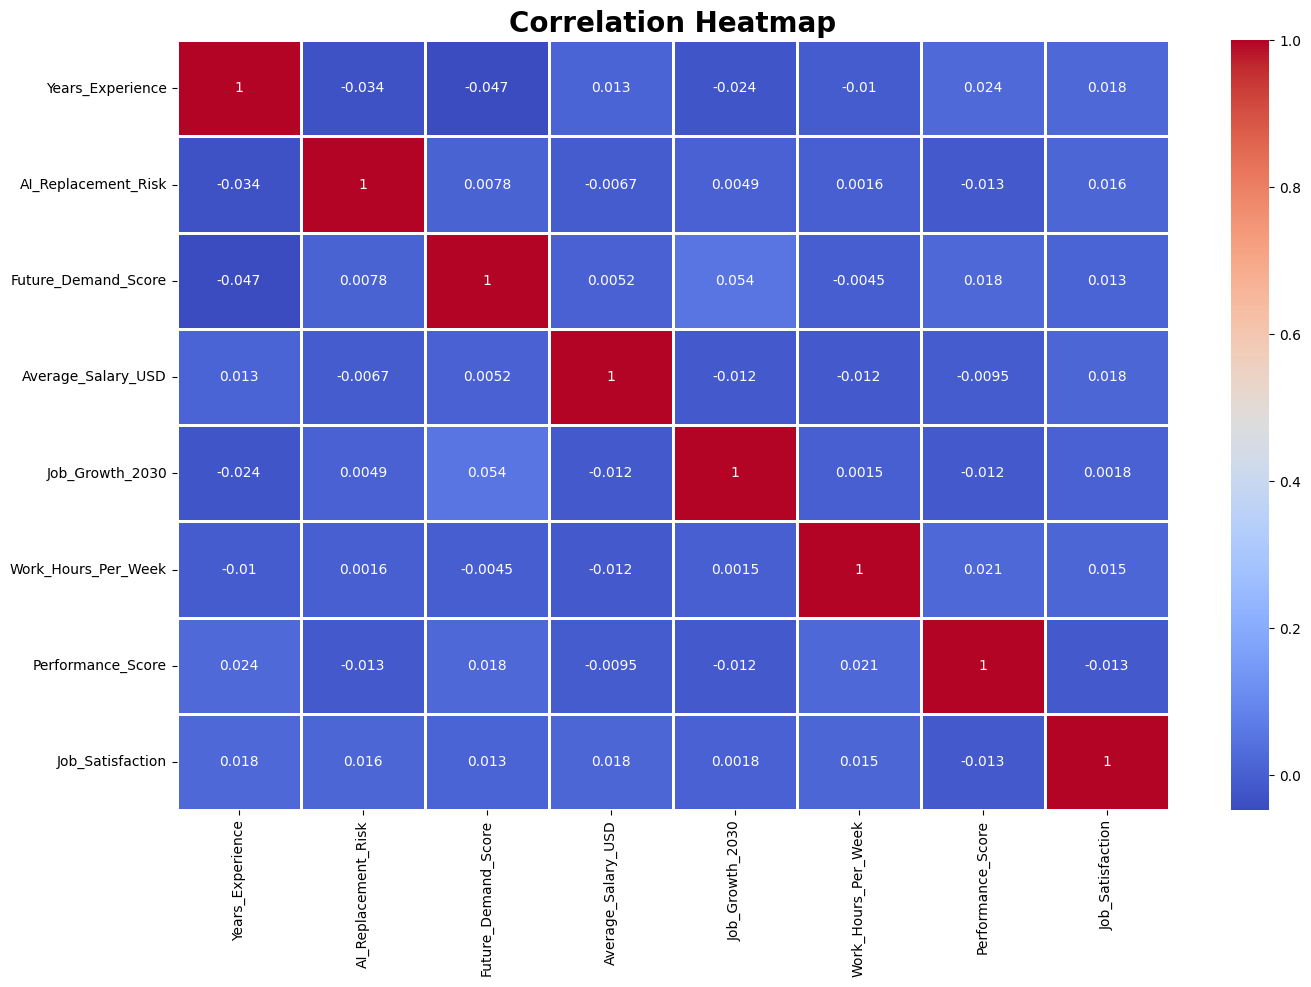

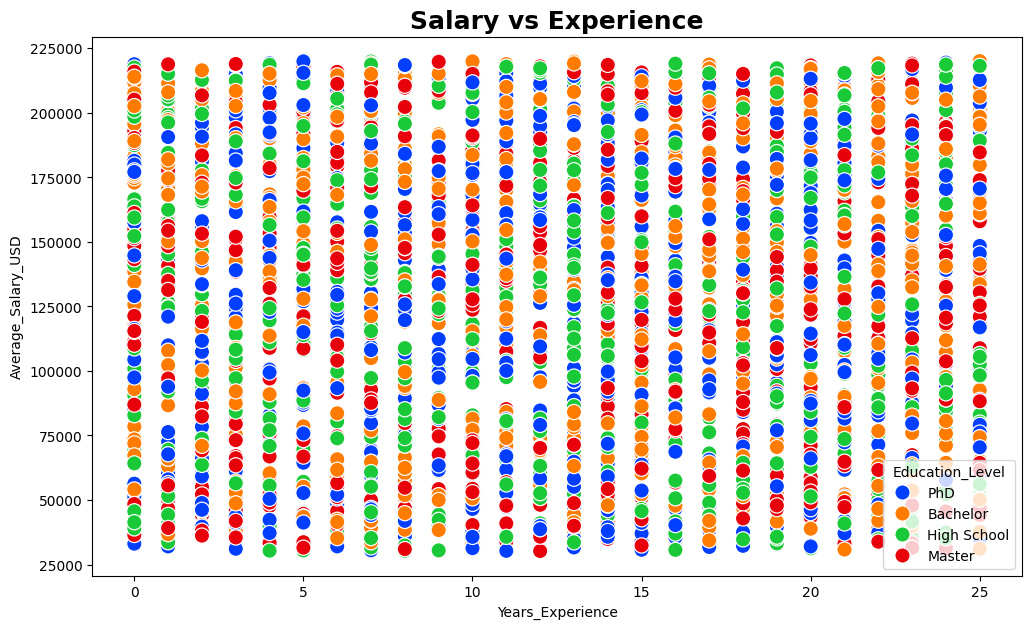

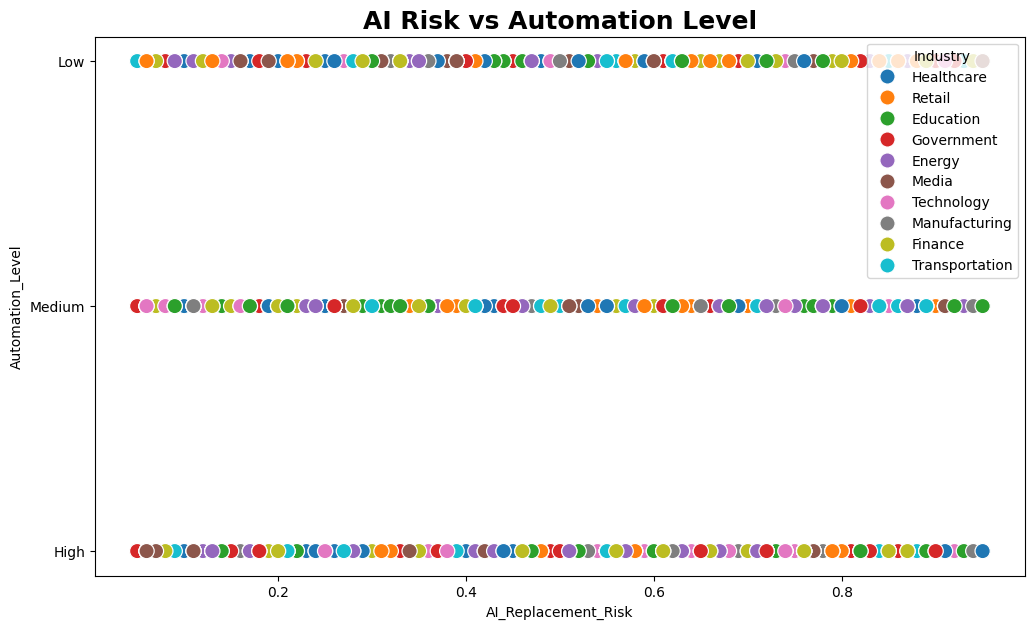

All Visualizations Generated Successfully!


In [11]:
# =========================================================
# AI JOB MARKET DATASET - DETAILED VISUALIZATION NOTEBOOK
# =========================================================

# ---------------------------
# IMPORT LIBRARIES
# ---------------------------

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# SETTINGS
# ---------------------------


print("Dataset Shape :", df.shape)
print("\nColumns :\n", df.columns)

display(df.head())

# =========================================================
# 1. JOB TITLE DISTRIBUTION
# =========================================================

plt.figure(figsize=(14,8))

colors = sns.color_palette("husl", len(df['Job_Title'].value_counts()))

sns.countplot(
    y=df['Job_Title'],
    order=df['Job_Title'].value_counts().index,
    palette=colors
)

plt.title('Job Title Distribution', fontsize=18, weight='bold')
plt.xlabel('Count')
plt.ylabel('Job Title')

plt.show()

# =========================================================
# 2. INDUSTRY DISTRIBUTION
# =========================================================

plt.figure(figsize=(12,7))

colors = sns.color_palette("Set2", len(df['Industry'].value_counts()))

sns.countplot(
    y=df['Industry'],
    order=df['Industry'].value_counts().index,
    palette=colors
)

plt.title('Industry Distribution', fontsize=18, weight='bold')
plt.xlabel('Count')
plt.ylabel('Industry')

plt.show()

# =========================================================
# 3. COUNTRY DISTRIBUTION
# =========================================================

plt.figure(figsize=(12,7))

colors = sns.color_palette("tab20", len(df['Country'].value_counts()))

sns.countplot(
    y=df['Country'],
    order=df['Country'].value_counts().index,
    palette=colors
)

plt.title('Country Distribution', fontsize=18, weight='bold')
plt.xlabel('Count')
plt.ylabel('Country')

plt.show()

# =========================================================
# 4. EDUCATION LEVEL
# =========================================================

plt.figure(figsize=(10,6))

colors = ['red','blue','green','orange','purple']

df['Education_Level'].value_counts().plot(
    kind='bar',
    color=colors
)

plt.title('Education Level Distribution', fontsize=18, weight='bold')
plt.xlabel('Education Level')
plt.ylabel('Count')

plt.xticks(rotation=30)

plt.show()

# =========================================================
# 5. YEARS OF EXPERIENCE
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Years_Experience'],
    bins=20,
    kde=True,
    color='darkblue'
)

plt.title('Years of Experience', fontsize=18, weight='bold')
plt.xlabel('Years')
plt.ylabel('Frequency')

plt.show()

# =========================================================
# 6. AI REPLACEMENT RISK
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['AI_Replacement_Risk'],
    bins=20,
    kde=True,
    color='crimson'
)

plt.title('AI Replacement Risk', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 7. FUTURE DEMAND SCORE
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Future_Demand_Score'],
    bins=20,
    kde=True,
    color='green'
)

plt.title('Future Demand Score', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 8. REMOTE WORK POSSIBILITY
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Remote_Work_Possibility',
    data=df,
    palette='cool'
)

plt.title('Remote Work Possibility', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 9. AVERAGE SALARY
# =========================================================

plt.figure(figsize=(12,6))

sns.histplot(
    df['Average_Salary_USD'],
    bins=30,
    kde=True,
    color='gold'
)

plt.title('Average Salary USD', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 10. REQUIRED SKILLS
# =========================================================

skills = df['Required_Skills'].str.split(',', expand=True).stack()

plt.figure(figsize=(14,8))

skills.value_counts().head(15).plot(
    kind='bar',
    color=sns.color_palette("viridis",15)
)

plt.title('Top 15 Required Skills', fontsize=18, weight='bold')
plt.xlabel('Skills')
plt.ylabel('Count')

plt.xticks(rotation=45)

plt.show()

# =========================================================
# 11. AUTOMATION LEVEL
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Automation_Level'],
    bins=20,
    kde=True,
    color='purple'
)

plt.title('Automation Level', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 12. JOB GROWTH 2030
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Job_Growth_2030'],
    bins=20,
    kde=True,
    color='teal'
)

plt.title('Job Growth 2030', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 13. WORK HOURS PER WEEK
# =========================================================

plt.figure(figsize=(10,6))

sns.boxplot(
    x=df['Work_Hours_Per_Week'],
    color='orange'
)

plt.title('Work Hours Per Week', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 14. COMPANY SIZE
# =========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='Company_Size',
    data=df,
    palette='magma'
)

plt.title('Company Size Distribution', fontsize=18, weight='bold')

plt.xticks(rotation=30)

plt.show()

# =========================================================
# 15. AI TOOL USAGE
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['AI_Tool_Usage'],
    bins=20,
    kde=True,
    color='brown'
)

plt.title('AI Tool Usage', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 16. PERFORMANCE SCORE
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Performance_Score'],
    bins=20,
    kde=True,
    color='darkgreen'
)

plt.title('Performance Score', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 17. UPSKILLING NEEDED
# =========================================================

plt.figure(figsize=(8,5))

sns.countplot(
    x='Upskilling_Needed',
    data=df,
    palette='Set1'
)

plt.title('Upskilling Needed', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 18. JOB SATISFACTION
# =========================================================

plt.figure(figsize=(10,6))

sns.histplot(
    df['Job_Satisfaction'],
    bins=20,
    kde=True,
    color='navy'
)

plt.title('Job Satisfaction', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 19. HIRING TREND 2026
# =========================================================

plt.figure(figsize=(10,6))

sns.countplot(
    x='Hiring_Trend_2026',
    data=df,
    palette='Spectral'
)

plt.title('Hiring Trend 2026', fontsize=18, weight='bold')

plt.xticks(rotation=30)

plt.show()

# =========================================================
# 20. CORRELATION HEATMAP
# =========================================================

numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(16,10))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    linewidths=1
)

plt.title('Correlation Heatmap', fontsize=20, weight='bold')

plt.show()

# =========================================================
# 21. SALARY VS EXPERIENCE
# =========================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='Years_Experience',
    y='Average_Salary_USD',
    hue='Education_Level',
    palette='bright',
    data=df,
    s=120
)

plt.title('Salary vs Experience', fontsize=18, weight='bold')

plt.show()

# =========================================================
# 22. AI RISK VS AUTOMATION LEVEL
# =========================================================

plt.figure(figsize=(12,7))

sns.scatterplot(
    x='AI_Replacement_Risk',
    y='Automation_Level',
    hue='Industry',
    palette='tab10',
    data=df,
    s=120
)

plt.title('AI Risk vs Automation Level', fontsize=18, weight='bold')

plt.show()

# =========================================================
# END
# =========================================================

print("All Visualizations Generated Successfully!")

## Features Engineering

Label Encoding Completed!

Feature Shape : (3000, 18)
Target Shape : (3000,)

Train Shape : (2400, 18)
Test Shape : (600, 18)

Number of Classes : 3

LOGISTIC REGRESSION

Accuracy : 0.345

Classification Report:

              precision    recall  f1-score   support

           0       0.31      0.26      0.28       196
           1       0.37      0.44      0.40       202
           2       0.35      0.34      0.34       202

    accuracy                           0.34       600
   macro avg       0.34      0.34      0.34       600
weighted avg       0.34      0.34      0.34       600


DECISION TREE

Accuracy : 0.34833333333333333

Classification Report:

              precision    recall  f1-score   support

           0       0.36      0.38      0.37       196
           1       0.35      0.28      0.31       202
           2       0.34      0.39      0.36       202

    accuracy                           0.35       600
   macro avg       0.35      0.35      0.35       600
weighted

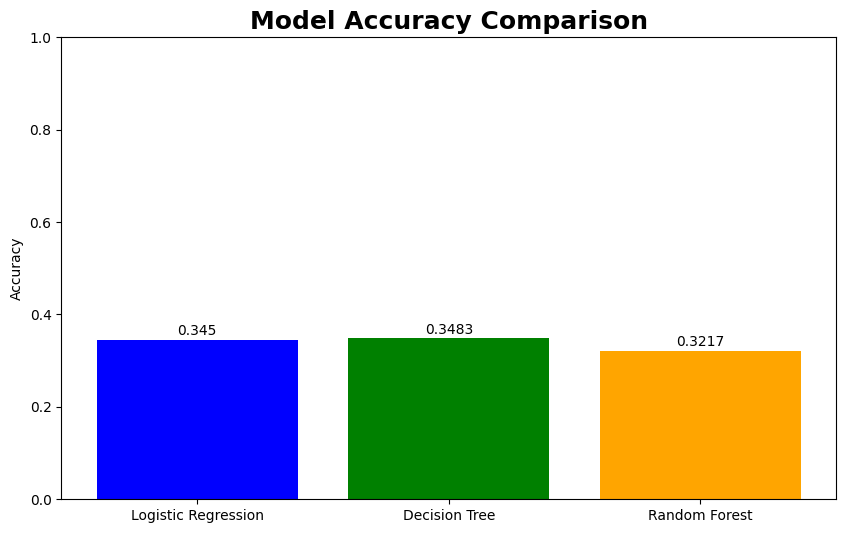

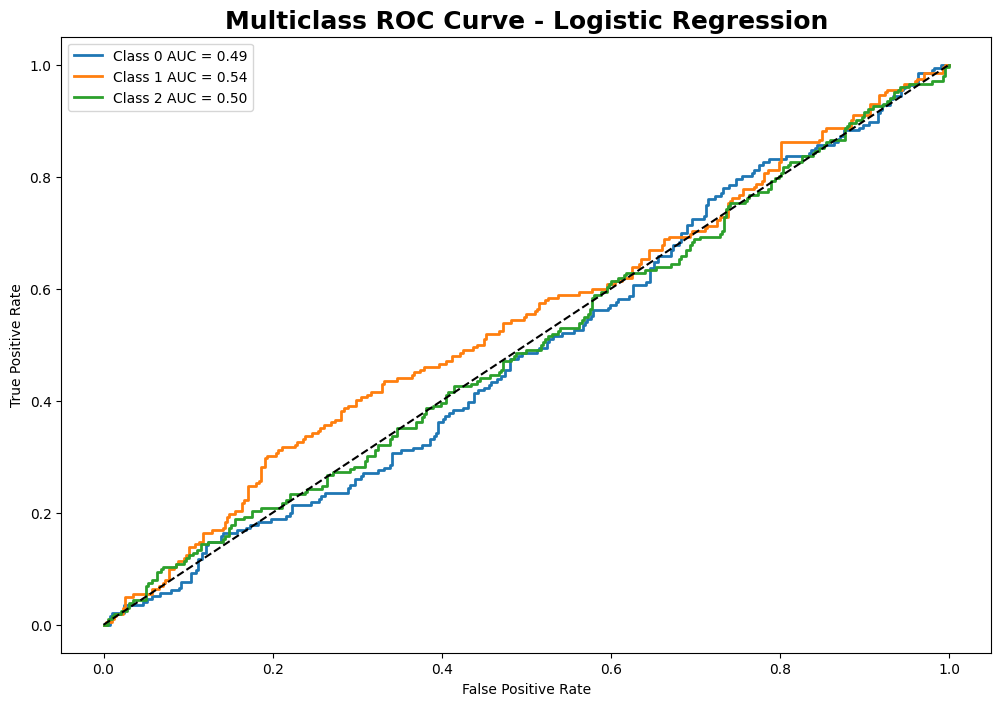

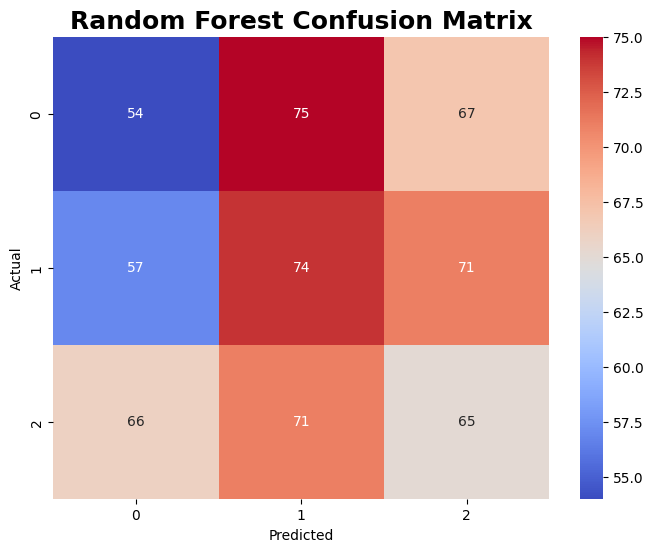

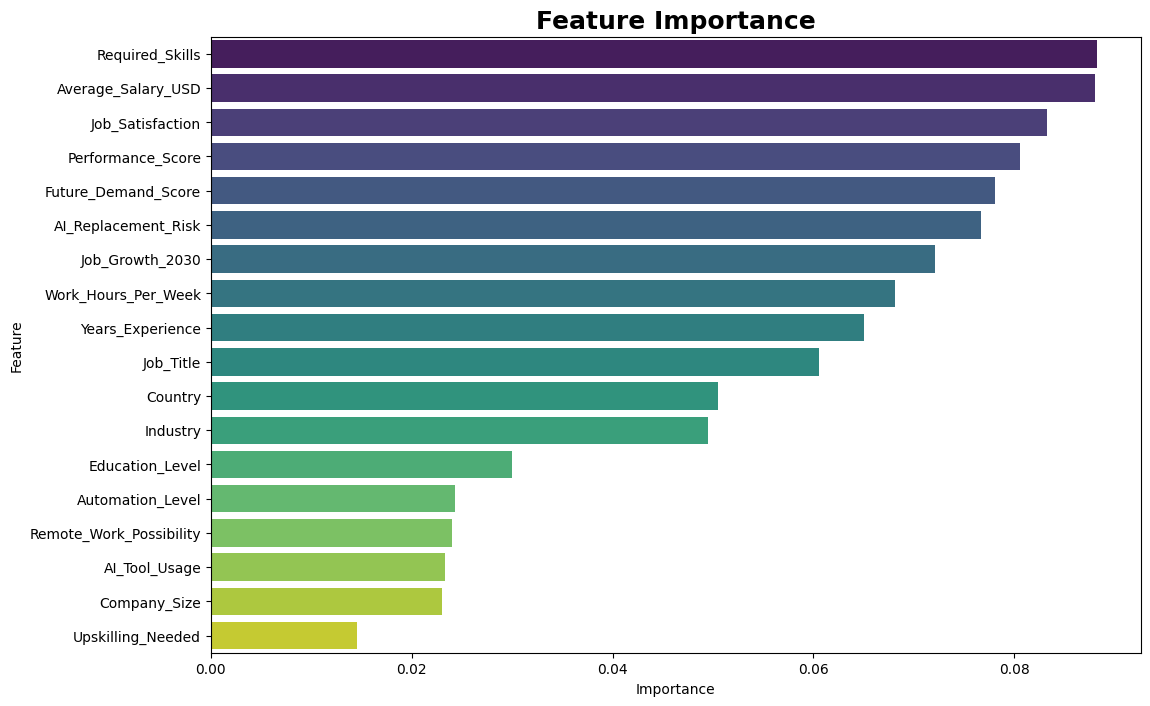


FINAL ACCURACY SCORES
Logistic Regression : 0.3450
Decision Tree       : 0.3483
Random Forest       : 0.3217

Best Accuracy : 0.3483

Machine Learning Pipeline Completed!


In [12]:
# =========================================================
# IMPORT LIBRARIES
# =========================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import label_binarize

from sklearn.model_selection import train_test_split

from sklearn.multiclass import OneVsRestClassifier

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)



df.drop('Employee_ID', axis=1, inplace=True)

# =========================================================
# LABEL ENCODING
# =========================================================

le_dict = {}

for col in df.columns:

    if df[col].dtype == 'object':

        le = LabelEncoder()

        df[col] = le.fit_transform(df[col])

        le_dict[col] = le

print("Label Encoding Completed!")

# =========================================================
# DEFINE FEATURES AND TARGET
# =========================================================

X = df.drop('Hiring_Trend_2026', axis=1)

y = df['Hiring_Trend_2026']

print("\nFeature Shape :", X.shape)
print("Target Shape :", y.shape)

# =========================================================
# TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Shape :", X_train.shape)
print("Test Shape :", X_test.shape)

# =========================================================
# FEATURE SCALING
# =========================================================
# Avoid Data Leakage
# Fit only on training data
# =========================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# =========================================================
# MULTICLASS TARGET BINARIZATION
# =========================================================

classes = np.unique(y)

y_test_bin = label_binarize(
    y_test,
    classes=classes
)

n_classes = y_test_bin.shape[1]

print("\nNumber of Classes :", n_classes)

# =========================================================
# LOGISTIC REGRESSION
# =========================================================

lr_model = OneVsRestClassifier(
    LogisticRegression()
)

lr_model.fit(X_train_scaled, y_train)

lr_pred = lr_model.predict(X_test_scaled)

lr_prob = lr_model.predict_proba(X_test_scaled)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("\n=================================")
print("LOGISTIC REGRESSION")
print("=================================")

print("\nAccuracy :", lr_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, lr_pred))

# =========================================================
# DECISION TREE
# =========================================================

dt_model = OneVsRestClassifier(
    DecisionTreeClassifier(
        max_depth=5,
        random_state=42
    )
)

dt_model.fit(X_train, y_train)

dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)

dt_accuracy = accuracy_score(y_test, dt_pred)

print("\n=================================")
print("DECISION TREE")
print("=================================")

print("\nAccuracy :", dt_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, dt_pred))

# =========================================================
# RANDOM FOREST
# =========================================================

rf_model = OneVsRestClassifier(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42
    )
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("\n=================================")
print("RANDOM FOREST")
print("=================================")

print("\nAccuracy :", rf_accuracy)

print("\nClassification Report:\n")

print(classification_report(y_test, rf_pred))

# =========================================================
# ACCURACY COMPARISON
# =========================================================

models = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest'
]

accuracies = [
    lr_accuracy,
    dt_accuracy,
    rf_accuracy
]

plt.figure(figsize=(10,6))

bars = plt.bar(
    models,
    accuracies,
    color=['blue','green','orange']
)

plt.title(
    'Model Accuracy Comparison',
    fontsize=18,
    weight='bold'
)

plt.ylabel('Accuracy')

plt.ylim(0,1)

for bar in bars:

    yval = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        yval + 0.01,
        round(yval,4),
        ha='center'
    )

plt.show()

# =========================================================
# MULTICLASS ROC CURVE
# =========================================================

# -----------------------------
# LOGISTIC REGRESSION ROC
# -----------------------------

plt.figure(figsize=(12,8))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        lr_prob[:, i]
    )

    auc_score = roc_auc_score(
        y_test_bin[:, i],
        lr_prob[:, i]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f'Class {i} AUC = {auc_score:.2f}'
    )

# Random baseline
plt.plot([0,1], [0,1], 'k--')

plt.title(
    'Multiclass ROC Curve - Logistic Regression',
    fontsize=18,
    weight='bold'
)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')

plt.legend()

plt.show()

# =========================================================
# CONFUSION MATRIX - RANDOM FOREST
# =========================================================

plt.figure(figsize=(8,6))

sns.heatmap(
    confusion_matrix(y_test, rf_pred),
    annot=True,
    fmt='d',
    cmap='coolwarm'
)

plt.title(
    'Random Forest Confusion Matrix',
    fontsize=18,
    weight='bold'
)

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

# =========================================================
# FEATURE IMPORTANCE
# =========================================================

rf_base = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_base.fit(X_train, y_train)

importance = rf_base.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

plt.figure(figsize=(12,8))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance,
    palette='viridis'
)

plt.title(
    'Feature Importance',
    fontsize=18,
    weight='bold'
)

plt.show()

# =========================================================
# FINAL RESULTS
# =========================================================

print("\n======================================")
print("FINAL ACCURACY SCORES")
print("======================================")

print(f"Logistic Regression : {lr_accuracy:.4f}")
print(f"Decision Tree       : {dt_accuracy:.4f}")
print(f"Random Forest       : {rf_accuracy:.4f}")

best_accuracy = max(
    lr_accuracy,
    dt_accuracy,
    rf_accuracy
)

print("\nBest Accuracy :", round(best_accuracy,4))

print("\nMachine Learning Pipeline Completed!")

## Thanks..............Please upvotes